# 05 — Training the NanoVLM

In the previous notebooks, we built each major component of our NanoVLM:

- Dataset and DataLoader
- CNN Image Encoder
- Transformer-based Text Encoder
- Symmetric CLIP-style Contrastive Loss

Now we connect these components and train them jointly.

The complete training flow is:

```text
Image
  ↓
Image Encoder
  ↓
Image Embedding
  ↓
                 Similarity Matrix
                 ↓
              Contrastive Loss
                 ↑
Text Embedding
  ↑
Text Encoder
  ↑
Tokenized Caption

In [399]:
# Core PyTorch imports

import random
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [400]:
from nano_vlm.data.tokenizer import (
    VOCAB,
    VOCAB_SIZE,
    PAD_TOKEN_ID,
    UNK_TOKEN_ID,
    BOS_TOKEN_ID,
    EOS_TOKEN_ID,
    tokenize_caption,
    tokenize_captions,
)

In [401]:
# ============================================================
# Load Dataset Artifacts and Recreate DataLoaders
# ============================================================

from pathlib import Path
import sys
import torch
from torch.utils.data import DataLoader


# ------------------------------------------------------------
# 1. Locate project root
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ------------------------------------------------------------
# 2. Import the dataset class
# ------------------------------------------------------------

from nano_vlm.data.dataset import SyntheticVLDataset
from nano_vlm.models.losses import contrastive_loss_fn

# ------------------------------------------------------------
# 3. Locate saved dataset artifacts
# ------------------------------------------------------------

DATASET_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "dataset"
)

train_samples_path = (
    DATASET_DIR / "train_samples.pt"
)

val_samples_path = (
    DATASET_DIR / "val_samples.pt"
)

FIGURES_DIR = PROJECT_ROOT / "assets" / "figures"

assert train_samples_path.exists(), (
    f"Training dataset not found:\n{train_samples_path}"
)

assert val_samples_path.exists(), (
    f"Validation dataset not found:\n{val_samples_path}"
)


# ------------------------------------------------------------
# 4. Load the saved samples
# ------------------------------------------------------------

train_samples = torch.load(
    train_samples_path,
    map_location="cpu",
    weights_only=False,
)

val_samples = torch.load(
    val_samples_path,
    map_location="cpu",
    weights_only=False,
)


print("Training samples:", len(train_samples))
print("Validation samples:", len(val_samples))


# ------------------------------------------------------------
# 5. Recreate Dataset objects
# ------------------------------------------------------------

train_dataset = SyntheticVLDataset(
    train_samples
)

val_dataset = SyntheticVLDataset(
    val_samples
)


# ------------------------------------------------------------
# 6. Recreate DataLoaders
# ------------------------------------------------------------

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


# ------------------------------------------------------------
# 7. Verify
# ------------------------------------------------------------

print("\nDataLoaders ready.")

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training samples: 194
Validation samples: 49

DataLoaders ready.
Train batches: 7
Validation batches: 2


## 3. Device Configuration

Training can run on either:

- CPU
- NVIDIA GPU through CUDA

We select the device automatically.

The same device must be used by:

- images
- token tensors
- Image Encoder
- Text Encoder
- loss calculations

Keeping all tensors and model parameters on the same device prevents device mismatch errors.

In [402]:
# Reproducibility

SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Select the training device.

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


Device: cpu


In [403]:

# ------------------------------------------------------------
# Load tokenizer configuration
# ------------------------------------------------------------
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

MODEL_ARTIFACTS_DIR = (
    ARTIFACTS_DIR / "models"
)
print(MODEL_ARTIFACTS_DIR)
tokenizer_config_path = (
    MODEL_ARTIFACTS_DIR / "tokenizer_config.pt"
)

assert tokenizer_config_path.exists(), (
    f"Tokenizer configuration not found:\n"
    f"{tokenizer_config_path}"
)

tokenizer_config = torch.load(
    tokenizer_config_path,
    map_location="cpu",
    weights_only=False,
)


# ------------------------------------------------------------
# Inspect configuration
# ------------------------------------------------------------

print("Tokenizer configuration:")
print(tokenizer_config)

d:\github\Build A NanoVLM From SCRATCH\artifacts\models
Tokenizer configuration:
{'context_window': 16, 'vocab': ['<PAD>', '<UNK>', '<BOS>', '<EOS>', 'red', 'green', 'blue', 'yellow', 'purple', 'orange', 'pink', 'brown', 'gray', 'square', 'circle', 'triangle', 'top-left', 'top-center', 'top-right', 'middle-left', 'center', 'middle-right', 'bottom-left', 'bottom-center', 'bottom-right']}


In [404]:
print("Configuration type:", type(tokenizer_config))

if isinstance(tokenizer_config, dict):
    print("Configuration keys:")
    print(list(tokenizer_config.keys()))

Configuration type: <class 'dict'>
Configuration keys:
['context_window', 'vocab']


## 4. Inspect the Existing DataLoader

Before writing the training loop, we need to verify exactly what one batch from the existing DataLoader contains.

This is especially important because the DataLoader may return more than two values.

In [405]:
# Get one batch from the existing DataLoader.

batch = next(iter(train_loader))

print("Batch type:", type(batch))

if isinstance(batch, dict):
    print("Batch keys:", batch.keys())

elif isinstance(batch, (tuple, list)):
    print("Number of batch elements:", len(batch))

    for i, item in enumerate(batch):
        if torch.is_tensor(item):
            print(
                f"Element {i}: tensor | "
                f"shape={item.shape} | "
                f"dtype={item.dtype}"
            )
        else:
            print(
                f"Element {i}: "
                f"type={type(item)}"
            )

else:
    print("Batch contents:", batch)

Batch type: <class 'dict'>
Batch keys: dict_keys(['image', 'caption', 'color', 'shape', 'position'])


In [406]:
# ============================================================
# NanoVLM Model Configuration
# ============================================================

# Context length
CONTEXT_WINDOW = tokenizer_config["context_window"]




# ------------------------------------------------------------
# Model dimensions
# ------------------------------------------------------------

EMBED_DIM = 64
ATTENTION_HEADS = 4
PROJECTION_DIM = 64


# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("NanoVLM Configuration")
print("=" * 40)

print("VOCAB_SIZE       :", VOCAB_SIZE)
print("PAD_TOKEN_ID     :", PAD_TOKEN_ID)
print("CONTEXT_WINDOW   :", CONTEXT_WINDOW)
print("EMBED_DIM        :", EMBED_DIM)
print("ATTENTION_HEADS  :", ATTENTION_HEADS)
print("PROJECTION_DIM   :", PROJECTION_DIM)
print("DEVICE            :", DEVICE)

NanoVLM Configuration
VOCAB_SIZE       : 25
PAD_TOKEN_ID     : 0
CONTEXT_WINDOW   : 16
EMBED_DIM        : 64
ATTENTION_HEADS  : 4
PROJECTION_DIM   : 64
DEVICE            : cpu


## 5. Extract Images and Captions from the Existing Batch

The previous cell tells us the actual DataLoader structure.

We now create a small helper that avoids hard-coding:

In [407]:
def unpack_batch(batch):
    """
    Extract images and text information from an existing DataLoader batch.

    This helper intentionally does not recreate or modify the dataset.
    """

    # --------------------------------------------------
    # Dictionary-style batch
    # --------------------------------------------------

    if isinstance(batch, dict):

        image_keys = [
            "image",
            "images",
            "pixel_values",
        ]

        text_keys = [
            "caption",
            "captions",
            "text",
            "texts",
            "tokens",
            "input_ids",
        ]

        images = None
        text = None

        for key in image_keys:
            if key in batch:
                images = batch[key]
                break

        for key in text_keys:
            if key in batch:
                text = batch[key]
                break

        if images is None or text is None:
            raise KeyError(
                "Could not identify images/text in batch dictionary. "
                f"Available keys: {list(batch.keys())}"
            )

        return images, text

    # --------------------------------------------------
    # Tuple/list-style batch
    # --------------------------------------------------

    if isinstance(batch, (tuple, list)):

        # Find the image tensor.
        image_candidates = [
            item
            for item in batch
            if torch.is_tensor(item)
            and item.ndim == 4
        ]

        if len(image_candidates) == 0:
            raise ValueError(
                "Could not find an image tensor with "
                "shape [B, C, H, W] in the batch."
            )

        images = image_candidates[0]

        # Find a likely text object.
        for item in batch:

            if item is images:
                continue

            # Token IDs
            if torch.is_tensor(item) and item.ndim == 2:
                return images, item

            # Captions as strings
            if isinstance(item, (list, tuple)):
                if len(item) > 0 and isinstance(
                    item[0],
                    str,
                ):
                    return images, item

        raise ValueError(
            "Found images but could not identify captions "
            "or token IDs in the batch."
        )

    raise TypeError(
        f"Unsupported batch type: {type(batch)}"
    )

In [408]:
# Test the batch extraction helper.

images, text_data = unpack_batch(batch)

print("Images shape:", images.shape)
print("Text data type:", type(text_data))

if torch.is_tensor(text_data):
    print("Text tensor shape:", text_data.shape)
    print("Text tensor dtype:", text_data.dtype)

elif isinstance(text_data, (list, tuple)):
    print("Number of text items:", len(text_data))

    if len(text_data) > 0:
        print("First caption:", text_data[0])

Images shape: torch.Size([32, 3, 32, 32])
Text data type: <class 'list'>
Number of text items: 32
First caption: yellow circle bottom-left


In [409]:
# ============================================================
# Load Contrastive Loss
# ============================================================


print("\nContrastive Loss Function:")
print(contrastive_loss_fn)


Contrastive Loss Function:
<function contrastive_loss_fn at 0x000001E79C796020>


In [410]:
# Create the two encoder branches.

image_encoder = ImageEncoder()

text_encoder = TextEncoder(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    max_length=CONTEXT_WINDOW,
    attention_heads=ATTENTION_HEADS,
    projection_dim=PROJECTION_DIM,
)


# Combine both branches into one NanoVLM.

model = NanoVLM(
    image_encoder=image_encoder,
    text_encoder=text_encoder,
).to(DEVICE)


print(model)

NanoVLM(
  (image_encoder): ImageEncoder(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (global_pool): AdaptiveAvgPool2d(output_size=1)
    (projection): Linear(in_features=256, out_features=64, bias=True)
  )
  (text_encoder): TextEncoder(
    (token_embedding): Embedding(25, 64)
    (attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
    )
    (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (projection): Linear(in_features=64, out_features=64, bias=True)
  )
)


In [411]:
# Check that both encoders are part of the same model.

print("Image Encoder:")
print(model.image_encoder)

print("\nText Encoder:")
print(model.text_encoder)

print("\nModel device:")
print(next(model.parameters()).device)

Image Encoder:
ImageEncoder(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (global_pool): AdaptiveAvgPool2d(output_size=1)
  (projection): Linear(in_features=256, out_features=64, bias=True)
)

Text Encoder:
TextEncoder(
  (token_embedding): Embedding(25, 64)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (projection): Linear(in_features=64, out_features=64, bias=True)
)

Model device:
cpu


## 7. Optimizer

The `NanoVLM` contains both trainable encoder branches:

```text
NanoVLM
├── Image Encoder
└── Text Encoder

In [412]:
# Training hyperparameters

LEARNING_RATE = 1e-3
NUM_EPOCHS = 20


# Optimize the complete NanoVLM.

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)


print("Learning rate:", LEARNING_RATE)
print("Epochs:", NUM_EPOCHS)

Learning rate: 0.001
Epochs: 20


## 8. Preparing Text for the Text Encoder

The existing DataLoader may provide either:

1. raw caption strings, or
2. token IDs.

We should not tokenize already-tokenized data a second time.

Therefore the training step checks the type of the text data.

If it is already a tensor:

```text
captions/tokens
↓
Text Encoder

In [413]:
def prepare_text(text_data):
    """
    Convert caption strings into token IDs.
    """

    if torch.is_tensor(text_data):
        return text_data.long()

    if isinstance(text_data, (list, tuple)):

        if len(text_data) == 0:
            raise ValueError("Empty text batch.")

        if isinstance(text_data[0], str):
            return tokenize_captions(
                text_data,
                max_length=CONTEXT_WINDOW,
            )

    raise TypeError(
        f"Unsupported text data type: {type(text_data)}"
    )

## 9. One Training Step

A single training step passes both modalities through the same `NanoVLM` model.

The process is:

```text
Image
  ↓
Image Encoder
  ↓
Image Embedding

Caption
  ↓
Text Encoder
  ↓
Text Embedding

Image Embedding + Text Embedding
              ↓
       Contrastive Loss
              ↓
        Backpropagation
              ↓
       NanoVLM Parameters
              ↓
        Optimizer Update

In [414]:
def train_one_epoch(
    model,
    train_loader,
    contrastive_loss_fn,
    optimizer,
    device,
):
    """
    Train the complete NanoVLM for one epoch.
    """

    model.train()

    total_loss = 0.0
    num_batches = 0

    for batch in train_loader:

        # ------------------------------------------
        # 1. Extract images and text
        # ------------------------------------------

        images, text_data = unpack_batch(batch)

        # ------------------------------------------
        # 2. Prepare text tokens
        # ------------------------------------------

        tokens = prepare_text(text_data)

        # ------------------------------------------
        # 3. Move tensors to device
        # ------------------------------------------

        images = images.to(device)
        tokens = tokens.to(device)

        # ------------------------------------------
        # 4. Clear previous gradients
        # ------------------------------------------

        optimizer.zero_grad()

        # ------------------------------------------
        # 5. Forward pass through NanoVLM
        # ------------------------------------------

        image_embeddings, text_embeddings = model(
            images,
            tokens,
        )

        # ------------------------------------------
        # 6. Contrastive loss
        # ------------------------------------------

        loss = contrastive_loss_fn(
            image_embeddings,
            text_embeddings,
        )

        # ------------------------------------------
        # 7. Backpropagation
        # ------------------------------------------

        loss.backward()

        # ------------------------------------------
        # 8. Update the complete model
        # ------------------------------------------

        optimizer.step()
        

        # ------------------------------------------
        # 9. Accumulate loss
        # ------------------------------------------

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

In [415]:
def validate(
    model,
    val_loader,
    contrastive_loss_fn,
    device,
):
    """
    Evaluate the NanoVLM on the validation set.
    """

    model.eval()

    total_loss = 0.0
    num_batches = 0

    with torch.no_grad():

        for batch in val_loader:

            # ------------------------------------------
            # 1. Extract images and text
            # ------------------------------------------

            images, text_data = unpack_batch(batch)

            # ------------------------------------------
            # 2. Prepare text tokens
            # ------------------------------------------

            tokens = prepare_text(text_data)

            # ------------------------------------------
            # 3. Move tensors to device
            # ------------------------------------------

            images = images.to(device)
            tokens = tokens.to(device)

            # ------------------------------------------
            # 4. Forward pass
            # ------------------------------------------

            image_embeddings, text_embeddings = model(
                images,
                tokens,
            )

            # ------------------------------------------
            # 5. Calculate validation loss
            # ------------------------------------------

            loss = contrastive_loss_fn(
                image_embeddings,
                text_embeddings,
            )

            total_loss += loss.item()
            num_batches += 1

    return total_loss / num_batches

## 10. Train the NanoVLM

We now train the complete `NanoVLM` end-to-end.

For every epoch:

1. Load a batch of image-text pairs.
2. Pass images through the Image Encoder.
3. Pass captions through the Text Encoder.
4. Calculate the image-text contrastive loss.
5. Backpropagate the loss.
6. Update the parameters of the complete `NanoVLM`.

Both encoder branches are therefore optimized together.

```text
                    NanoVLM
                       │
          ┌────────────┴────────────┐
          ↓                         ↓
   Image Encoder              Text Encoder
          ↓                         ↓
     Image Emb.                 Text Emb.
          └────────────┬────────────┘
                       ↓
               Contrastive Loss
                       ↓
                 Backpropagation
                       ↓
                 Adam Optimizer

In [416]:

train_losses=[]
val_losses=[]

In [417]:
for epoch in range(NUM_EPOCHS):

    train_loss = train_one_epoch(
        model=model,
        train_loader=train_loader,
        contrastive_loss_fn=contrastive_loss_fn,
        optimizer=optimizer,
        device=DEVICE,
    )

    val_loss = validate(
        model=model,
        val_loader=val_loader,
        contrastive_loss_fn=contrastive_loss_fn,
        device=DEVICE,
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
    )

Epoch 1/20 | Train Loss: 3.0610 | Val Loss: 3.0661
Epoch 2/20 | Train Loss: 2.7325 | Val Loss: 3.0596
Epoch 3/20 | Train Loss: 2.6006 | Val Loss: 2.3398
Epoch 4/20 | Train Loss: 1.7118 | Val Loss: 1.3505
Epoch 5/20 | Train Loss: 1.0697 | Val Loss: 1.0238
Epoch 6/20 | Train Loss: 0.8251 | Val Loss: 0.7308
Epoch 7/20 | Train Loss: 0.6356 | Val Loss: 0.7609
Epoch 8/20 | Train Loss: 0.4323 | Val Loss: 0.4363
Epoch 9/20 | Train Loss: 0.3970 | Val Loss: 0.2988
Epoch 10/20 | Train Loss: 0.2841 | Val Loss: 0.2456
Epoch 11/20 | Train Loss: 0.2079 | Val Loss: 0.1881
Epoch 12/20 | Train Loss: 0.1892 | Val Loss: 0.1534
Epoch 13/20 | Train Loss: 0.1353 | Val Loss: 0.1281
Epoch 14/20 | Train Loss: 0.1413 | Val Loss: 0.1164
Epoch 15/20 | Train Loss: 0.1346 | Val Loss: 0.1144
Epoch 16/20 | Train Loss: 0.1386 | Val Loss: 0.1809
Epoch 17/20 | Train Loss: 0.1295 | Val Loss: 0.1096
Epoch 18/20 | Train Loss: 0.0934 | Val Loss: 0.0999
Epoch 19/20 | Train Loss: 0.1003 | Val Loss: 0.0697
Epoch 20/20 | Train L

## 11. Monitoring Training

The most basic training signal is the contrastive loss.

We generally expect:

```text
training begins
      ↓
loss is relatively high
      ↓
model learns image-text relationships
      ↓
loss generally decreases

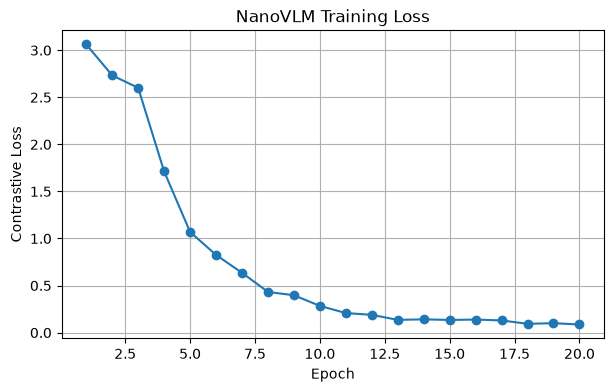

In [418]:
# Plot the training loss.

plt.figure(figsize=(7, 4))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o",
)

plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("NanoVLM Training Loss")

plt.grid(True)

plt.savefig(
    FIGURES_DIR / "NanoVLM_Training_Loss.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Training and Validation Curves

The training and validation losses show how the NanoVLM learns over time.

- **Training loss** shows how well the model fits the training batches.
- **Validation loss** shows how well the learned representation generalizes to unseen validation examples.

A healthy training process should generally show decreasing training loss. The validation loss should also decrease or stabilize rather than continuously increasing.

These curves help us understand the optimization process before we evaluate the final checkpoint in the next notebook.

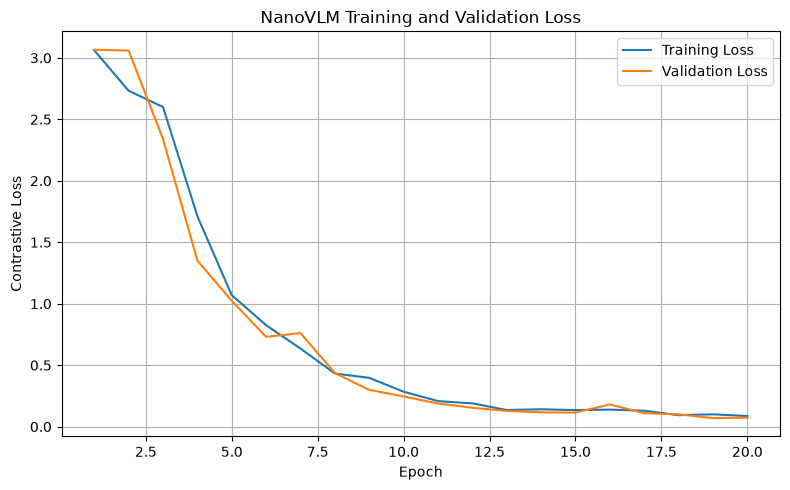

In [419]:
# ==================================================
# Training and Validation Loss Curves
# ==================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    label="Training Loss",
)

plt.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("NanoVLM Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "NanoVLM_Training_and_Validation_Loss.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


---

# 12. CHECKPOINT CELL


## Saving the Trained NanoVLM

The trained Image Encoder and Text Encoder are components of one `NanoVLM` model.

Therefore, we save the complete model using a single checkpoint.

The checkpoint contains:

- NanoVLM model parameters
- Optimizer state
- Training loss history
- Training configuration

This allows us to load the complete multimodal model later for evaluation or inference without retraining it.

In [420]:
from pathlib import Path


# --------------------------------------------------
# Locate the project root
# --------------------------------------------------


#
# project/
# ├── checkpoints/
# └── notebooks/
#     └── 06_training.ipynb

project_root = Path.cwd().parent

checkpoints_dir = project_root / "checkpoints"

checkpoints_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------
# Checkpoint path
# --------------------------------------------------

checkpoint_path = (
    checkpoints_dir / "nanovlm_checkpoint_new.pt"
)


# --------------------------------------------------
# Save the COMPLETE NanoVLM
# --------------------------------------------------

checkpoint = {
    "epoch": NUM_EPOCHS,

    # Complete NanoVLM parameters
    "model_state_dict": model.state_dict(),

    # Optimizer state
    "optimizer_state_dict": optimizer.state_dict(),

    # Training history
    "training_losses": train_losses,
    "validation_losses": val_losses,

    # Configuration
    "learning_rate": LEARNING_RATE,
    "projection_dim": PROJECTION_DIM,
    "embed_dim": EMBED_DIM,
    "attention_heads": ATTENTION_HEADS,
    "context_window": CONTEXT_WINDOW,
    "vocab_size": VOCAB_SIZE,
}


torch.save(
    checkpoint,
    checkpoint_path,
)


print("NanoVLM checkpoint saved successfully!")
print(f"Path: {checkpoint_path}")
print(
    f"Size: "
    f"{checkpoint_path.stat().st_size / 1024:.2f} KB"
)

NanoVLM checkpoint saved successfully!
Path: d:\github\Build A NanoVLM From SCRATCH\checkpoints\nanovlm_checkpoint_new.pt
Size: 5045.50 KB


## 13. Inspect the Learned Shared Embeddings

After training, we can use the single `NanoVLM` model to obtain embeddings from both modalities.

```text
NanoVLM
   │
   ├── encode_image(images)
   │        ↓
   │    [B, 64]
   │
   └── encode_text(tokens)
            ↓
         [B, 64]

In [421]:
# Switch the complete NanoVLM to evaluation mode.

model.eval()


# Get one batch.

batch = next(iter(train_loader))

images, text_data = unpack_batch(batch)

tokens = prepare_text(text_data)


# Move tensors to the selected device.

images = images.to(DEVICE)
tokens = tokens.to(DEVICE)


# Generate embeddings.

with torch.no_grad():

    image_embeddings, text_embeddings = model(
        images,
        tokens,
    )


# Normalize embeddings for cosine similarity.

image_embeddings = F.normalize(
    image_embeddings,
    dim=-1,
)

text_embeddings = F.normalize(
    text_embeddings,
    dim=-1,
)


# Calculate image-text similarity.

similarity_matrix = (
    image_embeddings @ text_embeddings.T
)


print("Images:", images.shape)

print(
    "Image embeddings:",
    image_embeddings.shape,
)

print(
    "Text embeddings:",
    text_embeddings.shape,
)

print(
    "Similarity matrix:",
    similarity_matrix.shape,
)

Images: torch.Size([32, 3, 32, 32])
Image embeddings: torch.Size([32, 64])
Text embeddings: torch.Size([32, 64])
Similarity matrix: torch.Size([32, 32])


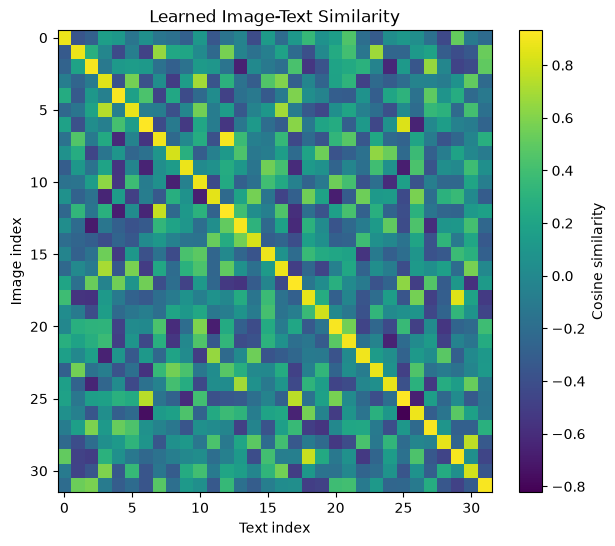

In [422]:
# Display the similarity matrix.

plt.figure(figsize=(7, 6))

plt.imshow(
    similarity_matrix.cpu().numpy(),
    aspect="auto",
)

plt.xlabel("Text index")
plt.ylabel("Image index")
plt.title("Learned Image-Text Similarity")

plt.colorbar(
    label="Cosine similarity"
)

plt.savefig(
    FIGURES_DIR / "NanoVLM_Learned_Image-Text_Similarity.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## 14. Qualitative Image-Text Retrieval

We can use the trained `NanoVLM` to perform a simple retrieval experiment.

For every image in a batch:

1. Encode the image using the Image Encoder.
2. Encode every caption using the Text Encoder.
3. Calculate image-text similarities.
4. Select the caption with the highest similarity.

Because the dataset contains aligned image-caption pairs, the correct caption is expected to have the same batch index as the image.

For example:

```text
Image 0
   ↓
NanoVLM Image Encoder
   ↓
Image Embedding
   ↓
Compare with all text embeddings
   ↓
Highest similarity → predicted caption

In [423]:
# Number of examples to inspect.

NUM_EXAMPLES_TO_SHOW = min(
    5,
    images.shape[0],
)


# Find the highest-scoring caption for each image.

predicted_caption_indices = similarity_matrix.argmax(
    dim=1
)


for image_index in range(
    NUM_EXAMPLES_TO_SHOW
):

    predicted_index = (
        predicted_caption_indices[
            image_index
        ].item()
    )

    print("=" * 60)

    print(
        f"Image index: {image_index}"
    )

    print(
        f"Predicted caption index: "
        f"{predicted_index}"
    )

    print(
        f"Actual matching caption index: "
        f"{image_index}"
    )

    # If raw captions are available, print them.

    if isinstance(
        text_data,
        (list, tuple)
    ):

        print(
            "Predicted caption:",
            text_data[predicted_index]
        )

        print(
            "Actual caption:",
            text_data[image_index]
        )

    print(
        "Predicted similarity:",
        similarity_matrix[
            image_index,
            predicted_index
        ].item()
    )

    print(
        "Correct-pair similarity:",
        similarity_matrix[
            image_index,
            image_index
        ].item()
    )

Image index: 0
Predicted caption index: 0
Actual matching caption index: 0
Predicted caption: blue square bottom-center
Actual caption: blue square bottom-center
Predicted similarity: 0.8871663212776184
Correct-pair similarity: 0.8871663212776184
Image index: 1
Predicted caption index: 1
Actual matching caption index: 1
Predicted caption: yellow circle middle-right
Actual caption: yellow circle middle-right
Predicted similarity: 0.882135272026062
Correct-pair similarity: 0.882135272026062
Image index: 2
Predicted caption index: 2
Actual matching caption index: 2
Predicted caption: orange triangle bottom-right
Actual caption: orange triangle bottom-right
Predicted similarity: 0.9064023494720459
Correct-pair similarity: 0.9064023494720459
Image index: 3
Predicted caption index: 3
Actual matching caption index: 3
Predicted caption: red square top-left
Actual caption: red square top-left
Predicted similarity: 0.853839099407196
Correct-pair similarity: 0.853839099407196
Image index: 4
Predi

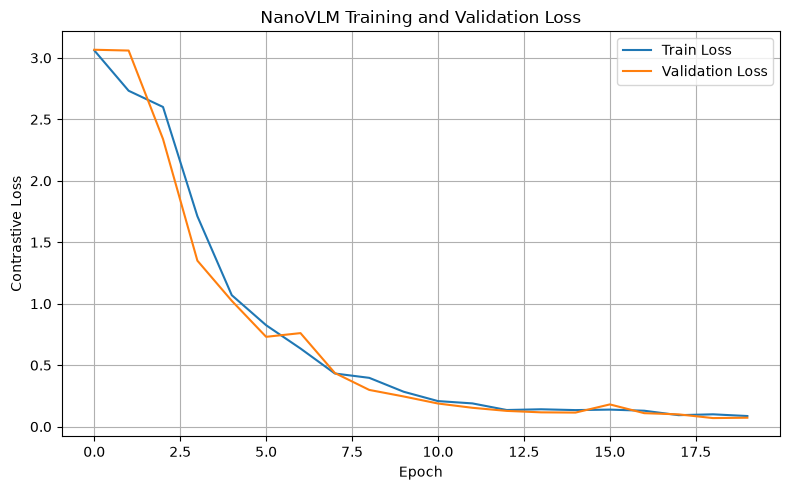

TRAINING OUTPUTS SAVED
Checkpoint:
d:\github\Build A NanoVLM From SCRATCH\checkpoints\nanovlm_checkpoint.pt

Training history:
d:\github\Build A NanoVLM From SCRATCH\artifacts\models\training_history.pt

Loss curve:
d:\github\Build A NanoVLM From SCRATCH\artifacts\figures\training_validation_loss.png

Final train loss: 0.08634130705779951
Final validation loss: 0.07267194055020809


In [424]:
# ============================================================
# Save Training Outputs and Final Checkpoint
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Checkpoint path
# ------------------------------------------------------------

checkpoint_path = (
    CHECKPOINTS_DIR / "nanovlm_checkpoint.pt"
)


# ------------------------------------------------------------
# Save complete NanoVLM checkpoint
# ------------------------------------------------------------

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": NUM_EPOCHS,
        "train_losses": train_losses,
        "val_losses": val_losses,
    },
    checkpoint_path,
)


# ------------------------------------------------------------
# Save loss history
# ------------------------------------------------------------

torch.save(
    {
        "train_losses": train_losses,
        "val_losses": val_losses,
    },
    MODEL_ARTIFACTS_DIR / "training_history.pt",
)


# ------------------------------------------------------------
# Training / validation curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Train Loss",
)

plt.plot(
    val_losses,
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("NanoVLM Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.tight_layout()

loss_curve_path = (
    PROJECT_ROOT
    / "artifacts"
    / "figures"
    / "training_validation_loss.png"
)

loss_curve_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    loss_curve_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Final confirmation
# ------------------------------------------------------------

print("=" * 60)
print("TRAINING OUTPUTS SAVED")
print("=" * 60)

print("Checkpoint:")
print(checkpoint_path)

print("\nTraining history:")
print(
    MODEL_ARTIFACTS_DIR
    / "training_history.pt"
)

print("\nLoss curve:")
print(loss_curve_path)

print("\nFinal train loss:", train_losses[-1])
print("Final validation loss:", val_losses[-1])

print("=" * 60)

# 15. Training Summary

We have now trained the complete NanoVLM.

The model consists of two encoder branches inside a single model:

```text
                    NanoVLM
                       │
             ┌─────────┴─────────┐
             ↓                   ↓
      Image Encoder        Text Encoder
             ↓                   ↓
        [B, 64]              [B, 64]
             └─────────┬─────────┘
                       ↓
              Shared Embedding Space
                       ↓
              Image-Text Similarity
                       ↓
               Contrastive Loss